In [24]:
# ============================================================
# BLOQUE 1 — CARGA ROBUSTA DEL EXPERIMENTO
# ============================================================

import os
import sys
import glob
import yaml
import joblib
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity
model = joblib.load(
    os.path.join(exp_dir, f"hmm_model_k{k}.pkl")
)

length_files = sorted(
    glob.glob(
        os.path.join(features_dir, "*_lengths.npy")
    )
)

# ------------------------------------------------------------
# ROOT
# ------------------------------------------------------------

project_root = os.path.abspath('../../')

if project_root not in sys.path:
    sys.path.append(project_root)

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------

def clean_path(yaml_path, root):
    limpio = yaml_path.replace('../../', '').replace('../', '')
    return os.path.normpath(os.path.join(root, limpio))

# ------------------------------------------------------------
# YAML DEL EXPERIMENTO
# ------------------------------------------------------------

yaml_path = '../../configs/experiments/feat_task_k3_diag_pca90_hjorthonly.yaml'

with open(yaml_path, 'r', encoding='utf-8') as f:
    cfg = yaml.safe_load(f)

exp_name = cfg['experiment']['name']

n_states = cfg['pipeline']['hmm']['k_states']

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

out_dir_base = clean_path(cfg['paths']['output_dir'], project_root)

exp_dir = os.path.join(out_dir_base, exp_name)

features_dir = clean_path(cfg['paths']['features_dir'], project_root)

# ------------------------------------------------------------
# LOAD VITERBI
# ------------------------------------------------------------

viterbi_paths = np.load(
    os.path.join(
        exp_dir,
        f'viterbi_paths_k{n_states}.npy'
    )
)

# ------------------------------------------------------------
# LOAD FEATURES
# ------------------------------------------------------------

feature_files = sorted(
    glob.glob(
        os.path.join(features_dir, '*_features.npy')
    )
)

X_original = np.vstack([
    np.load(f)
    for f in feature_files
])

# ------------------------------------------------------------
# LOAD SCALER
# ------------------------------------------------------------

scaler = joblib.load(
    os.path.join(exp_dir, 'scaler.pkl')
)

X_scaled = scaler.transform(X_original)

# ------------------------------------------------------------
# CHECKS
# ------------------------------------------------------------

print("=" * 60)
print("DEBUG DATA")
print("=" * 60)

print(f"Experiment: {exp_name}")
print(f"X_original: {X_original.shape}")
print(f"X_scaled:   {X_scaled.shape}")
print(f"Viterbi:    {viterbi_paths.shape}")

assert X_scaled.shape[0] == len(viterbi_paths)

print("\nCarga completada correctamente.")

DEBUG DATA
Experiment: feat_task_k3_diag_pca90_hjorthonly
X_original: (143899, 38)
X_scaled:   (143899, 38)
Viterbi:    (143899,)

Carga completada correctamente.


In [10]:
# ============================================================
# 1. CARGA DE CONFIGURACIÓN DEL EXPERIMENTO
# ============================================================

CONFIG_PATH = (
    "../../configs/experiments/"
    "feat_task_k3_diag_pca90_hjorthonly.yaml"
)

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

# ------------------------------------------------------------
# Metadata experimento
# ------------------------------------------------------------

exp_name = cfg["experiment"]["name"]

k = cfg["pipeline"]["hmm"]["k_states"]

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

exp_dir = os.path.join(
    "../../outputs/processed/experiments/feature_hmm/task/",
    exp_name
)

features_dir = cfg["paths"]["features_dir"].replace(
    "../../",
    "../../"
)

print("=" * 60)
print("EXPERIMENTO")
print("=" * 60)

print(f"Experimento: {exp_name}")
print(f"K states:    {k}")
print(f"Exp dir:     {exp_dir}")
print(f"Features:    {features_dir}")

EXPERIMENTO
Experimento: feat_task_k3_diag_pca90_hjorthonly
K states:    3
Exp dir:     ../../outputs/processed/experiments/feature_hmm/task/feat_task_k3_diag_pca90_hjorthonly
Features:    ../../data/interim/features/task_hjorthonly/


In [11]:
# ============================================================
# 3. FUNCIONES AUXILIARES
# ============================================================

STEP_SIZE_MS = 100
WINDOWS_PER_EPOCH = 61


def compute_dwell_time(path, state, step_ms=100):

    is_state = (path == state)

    diffs = np.diff(
        np.concatenate(
            ([0], is_state.view(np.int8), [0])
        )
    )

    starts = np.where(diffs == 1)[0]
    ends = np.where(diffs == -1)[0]

    if len(starts) == 0:
        return 0

    durations = (ends - starts) * step_ms

    return np.mean(durations)


def build_state_labels(n_states):

    return [f"S{i}" for i in range(n_states)]

COSINE SIMILARITY


,S0,S1,S2
S0,1.0000,-0.7645,-0.1043
S1,-0.7645,1.0000,-0.5614
S2,-0.1043,-0.5614,1.0000


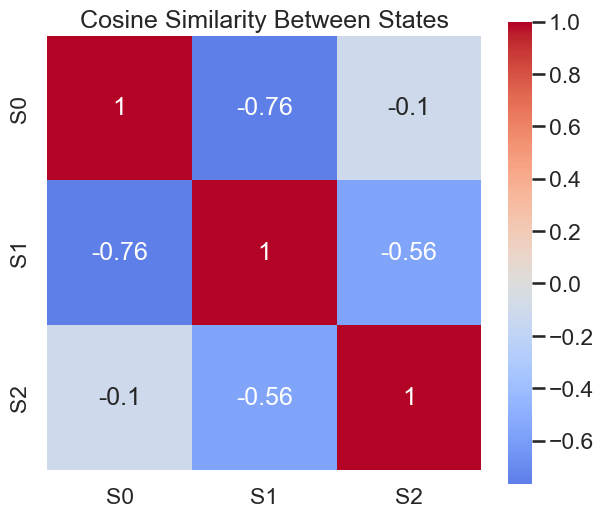

In [12]:
# ============================================================
# 4. STATE PROFILES Y COSINE SIMILARITY
# ============================================================
n_states=3
state_profiles = np.zeros(
    (n_states, X_scaled.shape[1])
)

for s in range(n_states):

    idx = (viterbi_paths == s)

    state_profiles[s] = np.mean(
        X_scaled[idx],
        axis=0
    )

# ------------------------------------------------------------
# Cosine similarity
# ------------------------------------------------------------

cos_sim = cosine_similarity(state_profiles)

cos_df = pd.DataFrame(
    np.round(cos_sim, 4),
    columns=build_state_labels(n_states),
    index=build_state_labels(n_states)
)

print("=" * 60)
print("COSINE SIMILARITY")
print("=" * 60)

display(cos_df)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(7, 6))

sns.heatmap(
    cos_sim,
    annot=True,
    cmap="coolwarm",
    center=0,
    square=True,
    xticklabels=build_state_labels(n_states),
    yticklabels=build_state_labels(n_states)
)

plt.title("Cosine Similarity Between States")
plt.show()

GLOBAL OCCUPANCY
State 0: 61.00% (n=87,780)
State 1: 31.40% (n=45,190)
State 2: 7.59% (n=10,929)


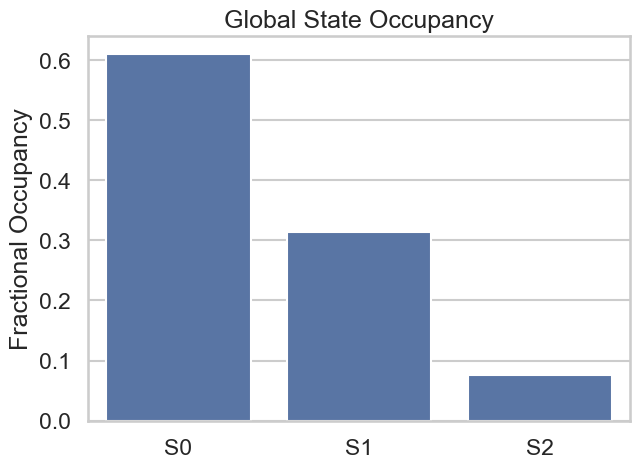

In [13]:
# ============================================================
# 5. GLOBAL OCCUPANCY
# ============================================================

total_windows = len(viterbi_paths)

occupancies = []

print("=" * 60)
print("GLOBAL OCCUPANCY")
print("=" * 60)

for s in range(n_states):

    n = np.sum(viterbi_paths == s)

    fo = n / total_windows

    occupancies.append(fo)

    print(
        f"State {s}: "
        f"{fo*100:.2f}% "
        f"(n={n:,})"
    )

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

sns.barplot(
    x=build_state_labels(n_states),
    y=occupancies
)

plt.ylabel("Fractional Occupancy")
plt.title("Global State Occupancy")

plt.show()

In [21]:
# ============================================================
# 6. TRANSITION MATRIX Y PERSISTENCIA
# ============================================================

transmat = model.transmat_

trans_df = pd.DataFrame(
    np.round(transmat, 4),
    columns=[f"To S{i}" for i in range(n_states)],
    index=[f"From S{i}" for i in range(n_states)]
)

print("=" * 60)
print("TRANSITION MATRIX")
print("=" * 60)

display(trans_df)

print("\n")

for s in range(n_states):

    persistence = transmat[s, s]

    fo = np.mean(viterbi_paths == s)

    print(
        f"State {s}\n"
        f"FO: {fo*100:.2f}%\n"
        f"Self-transition: {persistence:.4f}\n"
    )

TRANSITION MATRIX


,To S0,To S1,To S2
From S0,0.8420,0.1565,0.0014
From S1,0.2906,0.7048,0.0046
From S2,0.0099,0.0216,0.9685




State 0
FO: 61.00%
Self-transition: 0.8420

State 1
FO: 31.40%
Self-transition: 0.7048

State 2
FO: 7.59%
Self-transition: 0.9685



DWELL TIMES
State 0: 689.17 ms
State 1: 351.73 ms
State 2: 3301.81 ms


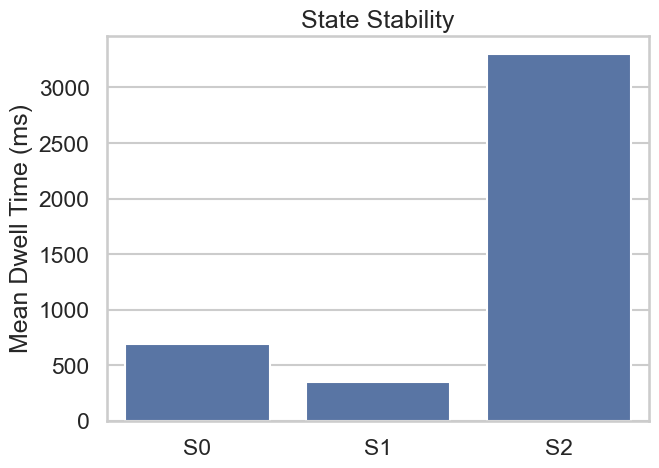

In [22]:
# ============================================================
# 7. DWELL TIMES
# ============================================================

dwells = []

print("=" * 60)
print("DWELL TIMES")
print("=" * 60)

for s in range(n_states):

    dt = compute_dwell_time(
        viterbi_paths,
        s,
        step_ms=STEP_SIZE_MS
    )

    dwells.append(dt)

    print(f"State {s}: {dt:.2f} ms")

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

sns.barplot(
    x=build_state_labels(n_states),
    y=dwells
)

plt.ylabel("Mean Dwell Time (ms)")
plt.title("State Stability")

plt.show()

SUBJECT-LEVEL OCCUPANCY


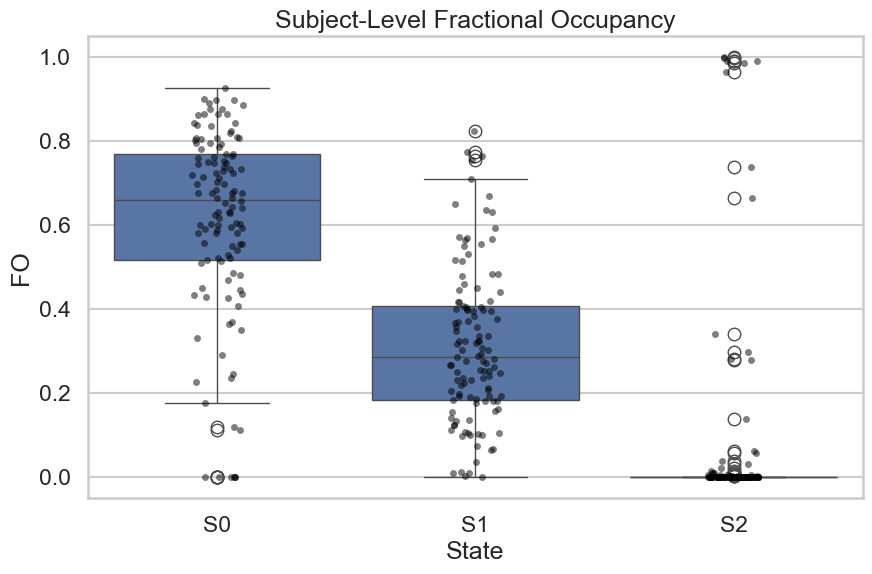

In [25]:
# ============================================================
# 8. SUBJECT-LEVEL OCCUPANCY
# ============================================================

subject_stats = []

start_idx = 0

print("=" * 60)
print("SUBJECT-LEVEL OCCUPANCY")
print("=" * 60)

for f_path in length_files:

    subj = os.path.basename(f_path).replace(
        "_lengths.npy",
        ""
    )

    lengths = np.load(f_path)

    subj_total = np.sum(lengths)

    subj_path = viterbi_paths[
        start_idx : start_idx + subj_total
    ]

    start_idx += subj_total

    for s in range(n_states):

        fo = np.mean(subj_path == s)

        subject_stats.append({
            "Subject": subj,
            "State": f"S{s}",
            "FO": fo
        })

df_subject = pd.DataFrame(subject_stats)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_subject,
    x="State",
    y="FO"
)

sns.stripplot(
    data=df_subject,
    x="State",
    y="FO",
    alpha=0.5,
    color="black"
)

plt.title("Subject-Level Fractional Occupancy")
plt.ylabel("FO")

plt.show()

TEMPORAL POSITION TEST


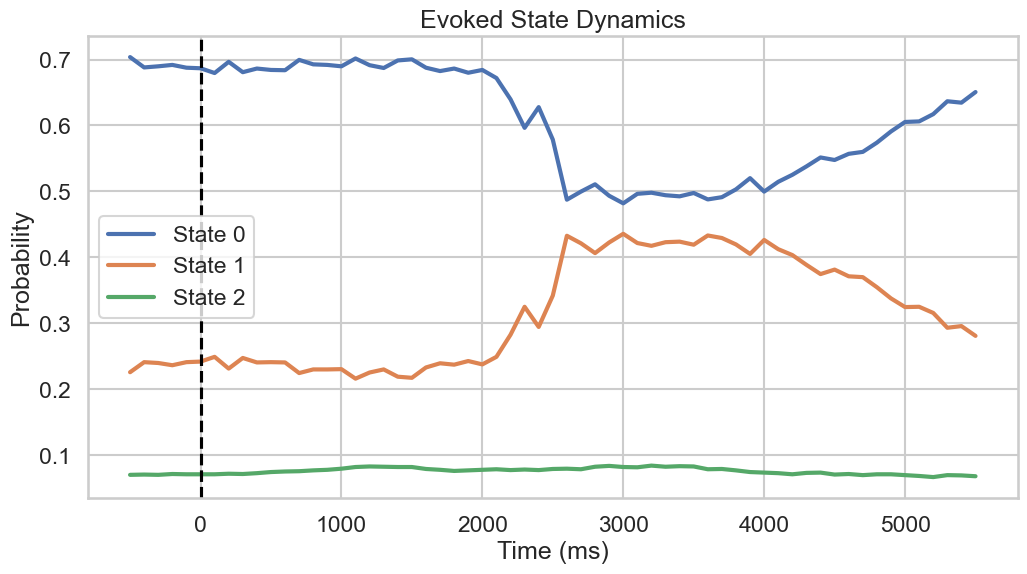

In [26]:
# ============================================================
# 9. EVOKED STATE DYNAMICS
# ============================================================

epochs = []

start = 0

print("=" * 60)
print("TEMPORAL POSITION TEST")
print("=" * 60)

for f_path in length_files:

    lengths = np.load(f_path)

    for l in lengths:

        ep = viterbi_paths[start:start+l]

        start += l

        if len(ep) == WINDOWS_PER_EPOCH:
            epochs.append(ep)

epochs = np.array(epochs)

# ------------------------------------------------------------
# Probabilidades temporales
# ------------------------------------------------------------

probabilities = np.zeros(
    (n_states, WINDOWS_PER_EPOCH)
)

for s in range(n_states):

    probabilities[s] = np.mean(
        epochs == s,
        axis=0
    )

time_axis = (
    np.arange(WINDOWS_PER_EPOCH) * STEP_SIZE_MS
    - 500
)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

for s in range(n_states):

    plt.plot(
        time_axis,
        probabilities[s],
        lw=3,
        label=f"State {s}"
    )

plt.axvline(
    0,
    linestyle="--",
    color="black"
)

plt.xlabel("Time (ms)")
plt.ylabel("Probability")

plt.title("Evoked State Dynamics")

plt.legend()

plt.show()

EUCLIDEAN DISTANCES


,S0,S1,S2
S0,0.000,2.715,5.643
S1,2.715,0.000,6.828
S2,5.643,6.828,0.000


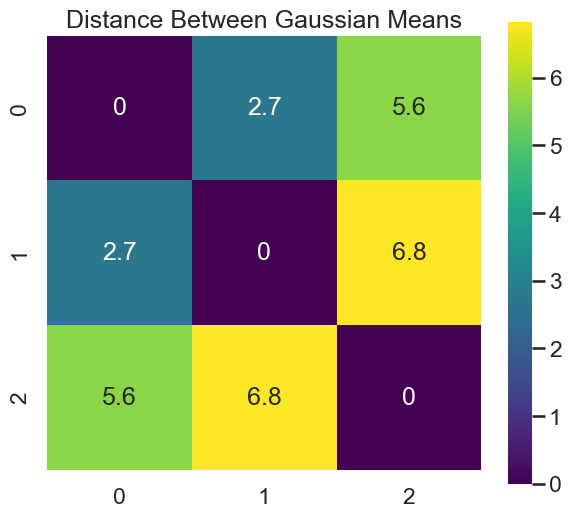

In [27]:
# ============================================================
# 10. DISTANCIAS ENTRE MEDIAS GAUSSIANAS
# ============================================================

means = model.means_

distances = cdist(
    means,
    means,
    metric="euclidean"
)

dist_df = pd.DataFrame(
    np.round(distances, 3),
    columns=build_state_labels(n_states),
    index=build_state_labels(n_states)
)

print("=" * 60)
print("EUCLIDEAN DISTANCES")
print("=" * 60)

display(dist_df)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(7, 6))

sns.heatmap(
    distances,
    annot=True,
    cmap="viridis",
    square=True
)

plt.title("Distance Between Gaussian Means")

plt.show()

In [29]:
print(covars.shape)

(3, 26, 26)


Covars shape: (3, 26, 26)
STATE VARIANCES
State 0: mean variance = 0.0307
State 1: mean variance = 0.0751
State 2: mean variance = 0.0345


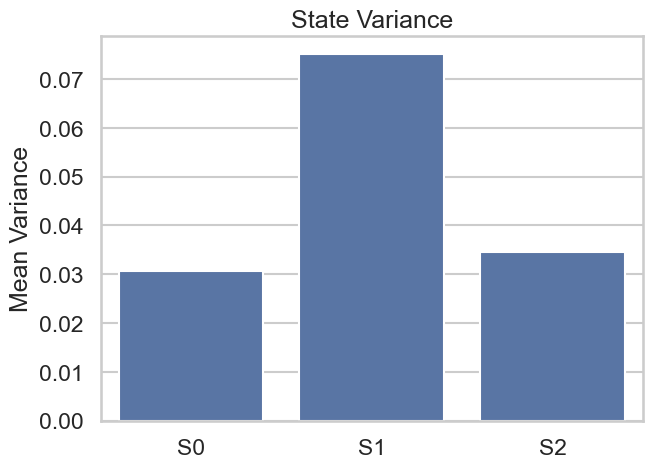

In [30]:
# ============================================================
# 11. VARIANZA DE ESTADOS
# ============================================================

covars = model.covars_

print("Covars shape:", covars.shape)

# ------------------------------------------------------------
# Mean variance per state
# ------------------------------------------------------------

if covars.ndim == 3:
    # full covariance
    state_var = np.mean(covars, axis=(1, 2))

elif covars.ndim == 2:
    # diagonal covariance
    state_var = np.mean(covars, axis=1)

else:
    raise ValueError(
        f"Unexpected covars ndim: {covars.ndim}"
    )

# ------------------------------------------------------------
# Print
# ------------------------------------------------------------

print("=" * 60)
print("STATE VARIANCES")
print("=" * 60)

for s in range(n_states):

    print(
        f"State {s}: "
        f"mean variance = {float(state_var[s]):.4f}"
    )

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

sns.barplot(
    x=[f"S{i}" for i in range(n_states)],
    y=state_var
)

plt.ylabel("Mean Variance")
plt.title("State Variance")

plt.show()

# test 1


STATE 2 SUBJECT OCCUPANCY


,Subject,FO
0,AAELSCGO_sin_contexto,0.000000
1,AAELSCNG_sin_contexto,0.000000
5,ACBSINNG_sin_contexto,0.000000
4,ACBSINGO_sin_contexto,0.000000
6,ACSSINGO_sin_contexto,0.000000
...,...,...
40,FVGSINGO_sin_contexto,0.986885
41,FVGSINNG_sin_contexto,0.990164
18,CGMSINGO_sin_contexto,0.990164
103,SEOOSINNG_sin_contexto,0.998361




count    118.000000
mean       0.075917
std        0.236816
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        1.000000
Name: FO, dtype: float64


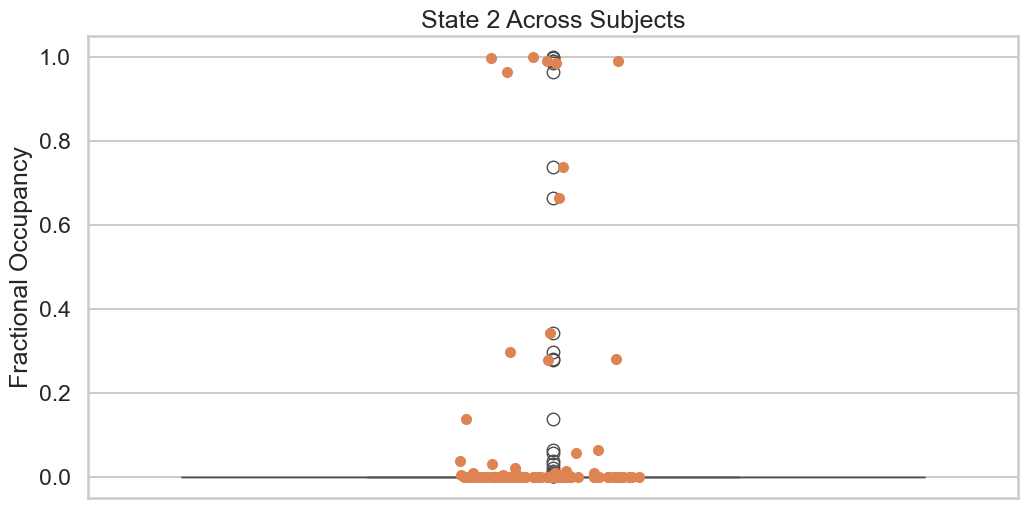

In [31]:
# ============================================================
# TEST 1 — SUBJECT-LEVEL OCCUPANCY
# ¿El estado pequeño aparece en TODOS los sujetos?
# ============================================================

TARGET_STATE = 2

required = [
    "viterbi_paths",
    "length_files",
    "n_states"
]

missing = [
    v for v in required
    if v not in globals()
]

if missing:
    raise RuntimeError(f"Missing variables: {missing}")

# ------------------------------------------------------------
# Build subject-level occupancy
# ------------------------------------------------------------

subject_stats = []

start_idx = 0

for f_path in length_files:

    subj = os.path.basename(f_path).replace(
        "_lengths.npy",
        ""
    )

    lengths = np.load(f_path)

    subj_total = np.sum(lengths)

    subj_path = viterbi_paths[
        start_idx : start_idx + subj_total
    ]

    start_idx += subj_total

    fo = np.mean(subj_path == TARGET_STATE)

    subject_stats.append({
        "Subject": subj,
        "FO": fo
    })

df_subject = pd.DataFrame(subject_stats)

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("=" * 60)
print(f"STATE {TARGET_STATE} SUBJECT OCCUPANCY")
print("=" * 60)

display(df_subject.sort_values("FO"))

print("\n")

print(df_subject["FO"].describe())

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

sns.boxplot(
    y=df_subject["FO"]
)

sns.stripplot(
    y=df_subject["FO"],
    size=8
)

plt.ylabel("Fractional Occupancy")

plt.title(
    f"State {TARGET_STATE} Across Subjects"
)

plt.show()

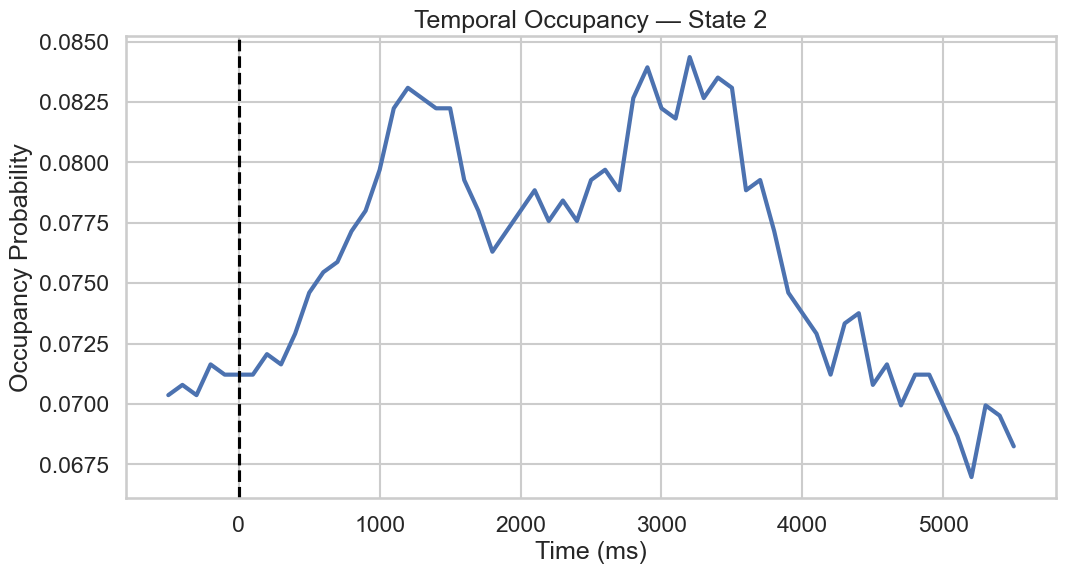

In [32]:
# ============================================================
# TEST 2 — OCCUPANCY OVER TIME
# ¿El estado aparece solo en ciertas épocas?
# ============================================================

TARGET_STATE = 2
WINDOWS_PER_EPOCH = 61
STEP_SIZE_MS = 100

required = [
    "viterbi_paths",
    "length_files"
]

missing = [
    v for v in required
    if v not in globals()
]

if missing:
    raise RuntimeError(f"Missing variables: {missing}")

# ------------------------------------------------------------
# Build epochs
# ------------------------------------------------------------

epochs = []

start = 0

for f_path in length_files:

    lengths = np.load(f_path)

    for l in lengths:

        ep = viterbi_paths[start:start+l]

        start += l

        if len(ep) == WINDOWS_PER_EPOCH:
            epochs.append(ep)

epochs = np.array(epochs)

# ------------------------------------------------------------
# Probability over time
# ------------------------------------------------------------

occupancy_over_time = np.mean(
    epochs == TARGET_STATE,
    axis=0
)

time_axis = (
    np.arange(WINDOWS_PER_EPOCH) * STEP_SIZE_MS
    - 500
)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

plt.plot(
    time_axis,
    occupancy_over_time,
    lw=3
)

plt.axvline(
    0,
    linestyle="--",
    color="black"
)

plt.xlabel("Time (ms)")
plt.ylabel("Occupancy Probability")

plt.title(
    f"Temporal Occupancy — State {TARGET_STATE}"
)

plt.show()

MEANS SHAPE
(3, 26)
EUCLIDEAN DISTANCES


,S0,S1,S2
S0,0.000,2.715,5.643
S1,2.715,0.000,6.828
S2,5.643,6.828,0.000


COSINE SIMILARITY


,S0,S1,S2
S0,1.000,-0.759,-0.099
S1,-0.759,1.000,-0.573
S2,-0.099,-0.573,1.000


MEAN VECTOR NORMS


,State,Norm
0,S0,0.874331
1,S1,1.991560
2,S2,5.489291


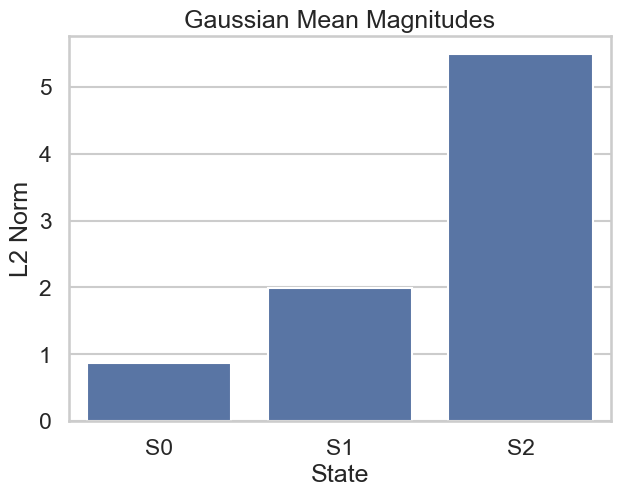

In [33]:
# ============================================================
# TEST 3 — GAUSSIAN EMISSIONS
# ============================================================

required = [
    "model",
    "n_states"
]

missing = [
    v for v in required
    if v not in globals()
]

if missing:
    raise RuntimeError(f"Missing variables: {missing}")

# ------------------------------------------------------------
# Means
# ------------------------------------------------------------

means = model.means_

print("=" * 60)
print("MEANS SHAPE")
print("=" * 60)

print(means.shape)

# ------------------------------------------------------------
# Euclidean distance
# ------------------------------------------------------------

distances = cdist(
    means,
    means,
    metric="euclidean"
)

dist_df = pd.DataFrame(
    np.round(distances, 3),
    columns=[f"S{i}" for i in range(n_states)],
    index=[f"S{i}" for i in range(n_states)]
)

print("=" * 60)
print("EUCLIDEAN DISTANCES")
print("=" * 60)

display(dist_df)

# ------------------------------------------------------------
# Cosine similarity
# ------------------------------------------------------------

cos_sim = cosine_similarity(means)

cos_df = pd.DataFrame(
    np.round(cos_sim, 3),
    columns=[f"S{i}" for i in range(n_states)],
    index=[f"S{i}" for i in range(n_states)]
)

print("=" * 60)
print("COSINE SIMILARITY")
print("=" * 60)

display(cos_df)

# ------------------------------------------------------------
# Norm magnitudes
# ------------------------------------------------------------

norms = np.linalg.norm(
    means,
    axis=1
)

norm_df = pd.DataFrame({
    "State": [f"S{i}" for i in range(n_states)],
    "Norm": norms
})

print("=" * 60)
print("MEAN VECTOR NORMS")
print("=" * 60)

display(norm_df)

# ------------------------------------------------------------
# Plot norms
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

sns.barplot(
    data=norm_df,
    x="State",
    y="Norm"
)

plt.title("Gaussian Mean Magnitudes")

plt.ylabel("L2 Norm")

plt.show()

# test 2


Epoch matrix: (2359, 61)


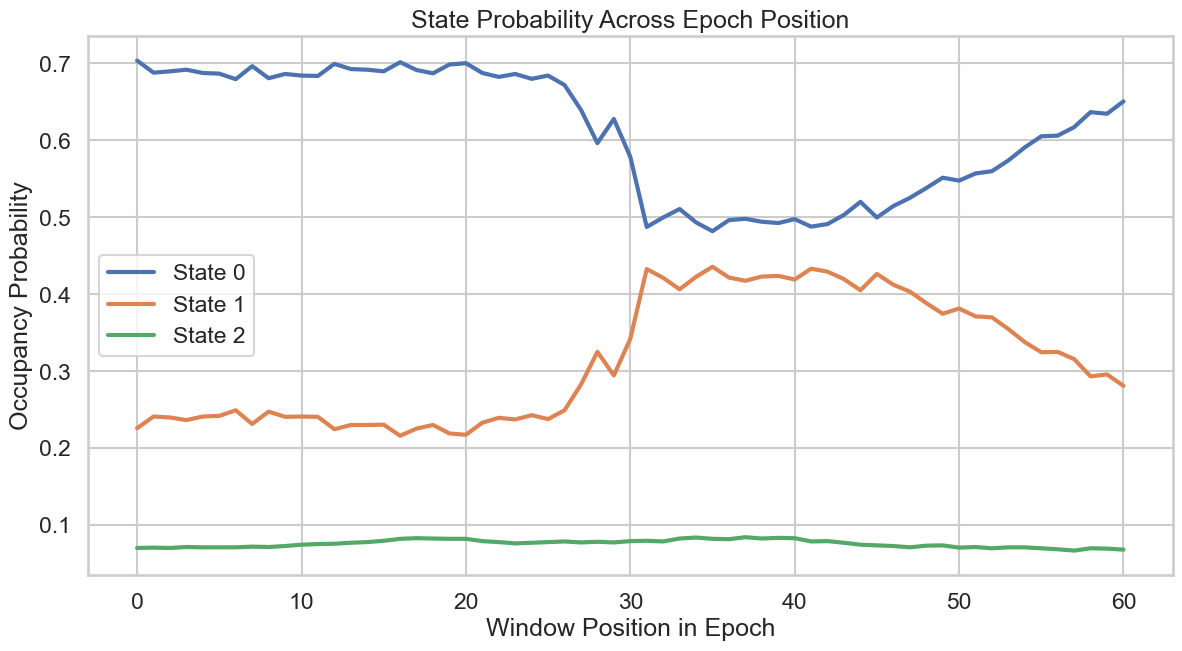

In [34]:
# ============================================================
# TEST 1 — POSITION WITHIN EPOCH
# ============================================================

WINDOWS_PER_EPOCH = 61

required = [
    "viterbi_paths",
    "length_files",
    "n_states"
]

missing = [
    v for v in required
    if v not in globals()
]

if missing:
    raise RuntimeError(f"Missing variables: {missing}")

# ------------------------------------------------------------
# Build epochs
# ------------------------------------------------------------

epochs = []

start = 0

for f_path in length_files:

    lengths = np.load(f_path)

    for l in lengths:

        ep = viterbi_paths[start:start+l]

        start += l

        if len(ep) == WINDOWS_PER_EPOCH:
            epochs.append(ep)

epochs = np.array(epochs)

print("Epoch matrix:", epochs.shape)

# ------------------------------------------------------------
# Position counts
# ------------------------------------------------------------

position_counts = np.zeros(
    (n_states, WINDOWS_PER_EPOCH)
)

for s in range(n_states):

    position_counts[s] = np.mean(
        epochs == s,
        axis=0
    )

# ------------------------------------------------------------
# Plot all states
# ------------------------------------------------------------

time_axis = np.arange(WINDOWS_PER_EPOCH)

plt.figure(figsize=(14, 7))

for s in range(n_states):

    plt.plot(
        time_axis,
        position_counts[s],
        lw=3,
        label=f"State {s}"
    )

plt.xlabel("Window Position in Epoch")
plt.ylabel("Occupancy Probability")

plt.title("State Probability Across Epoch Position")

plt.legend()

plt.show()

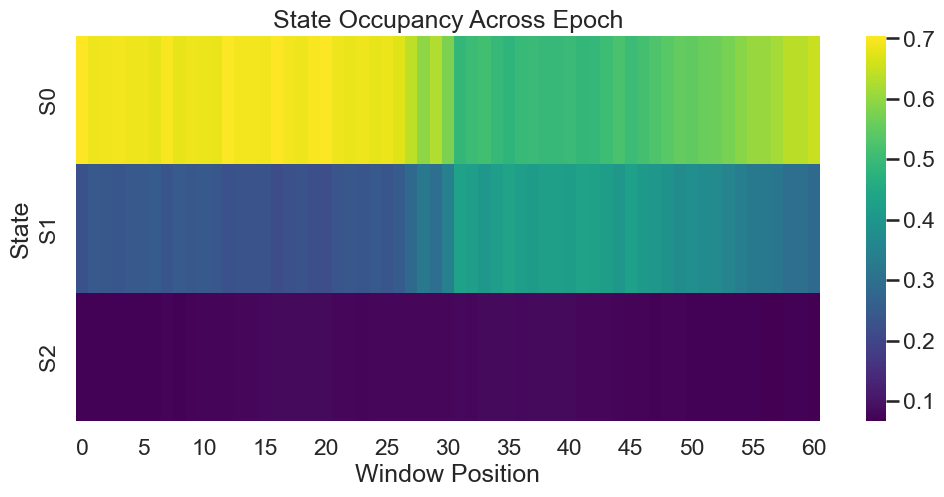

In [35]:
# ============================================================
# HEATMAP POSITION COUNTS
# ============================================================

plt.figure(figsize=(12, 5))

sns.heatmap(
    position_counts,
    cmap="viridis",
    xticklabels=5,
    yticklabels=[f"S{i}" for i in range(n_states)]
)

plt.xlabel("Window Position")
plt.ylabel("State")

plt.title("State Occupancy Across Epoch")

plt.show()

In [36]:
# ============================================================
# TEST 4 — SOFT DECODING
# ============================================================

required = [
    "model",
    "X_scaled",
    "viterbi_paths"
]

missing = [
    v for v in required
    if v not in globals()
]

if missing:
    raise RuntimeError(f"Missing variables: {missing}")

# ------------------------------------------------------------
# Posterior probabilities
# ------------------------------------------------------------

posterior_probs = model.predict_proba(X_scaled)

print("Posterior shape:", posterior_probs.shape)

# ------------------------------------------------------------
# Maximum confidence
# ------------------------------------------------------------

max_confidence = np.max(
    posterior_probs,
    axis=1
)

# ------------------------------------------------------------
# Entropy
# ------------------------------------------------------------

entropy = -np.sum(
    posterior_probs * np.log(posterior_probs + 1e-12),
    axis=1
)

# ------------------------------------------------------------
# Plot confidence
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))

plt.plot(max_confidence)

plt.title("Maximum State Confidence")

plt.ylabel("Confidence")
plt.xlabel("Window")

plt.show()

ValueError: operands could not be broadcast together with shapes (143899,1,38) (3,26) 

In [37]:
# ============================================================
# CONFIDENCE BY STATE
# ============================================================

state_conf = []

for s in range(n_states):

    idx = (viterbi_paths == s)

    conf = np.mean(
        max_confidence[idx]
    )

    ent = np.mean(
        entropy[idx]
    )

    state_conf.append({
        "State": f"S{s}",
        "MeanConfidence": conf,
        "MeanEntropy": ent
    })

df_conf = pd.DataFrame(state_conf)

display(df_conf)

NameError: name 'max_confidence' is not defined